<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
General Model Comparison: CV RMSE Across Regressors
</p>

In [1]:
# Imports - core utils, data wrangling, and plotting

import os
import re

import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Setup: Data Paths &amp; Plot Style
</p>

In [2]:
# Setup - shared data paths, global plot style, and reusable plotting helpers

CV_RESULTS_DIR = "CV_Results"
FIGURES_DIR    = "Figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

CV_RESULTS_PATHS = {  # RF / XGBoost / LightGBM Bayesian CV results
    "RF":       os.path.join(CV_RESULTS_DIR, "rf_bayes_cv_results.csv"),
    "XGBoost":  os.path.join(CV_RESULTS_DIR, "xgb_bayes_cv_results.csv"),
    "LightGBM": os.path.join(CV_RESULTS_DIR, "lgb_bayes_cv_results.csv"),
}

# kNN BayesSearchCV cv_results_ table from 06_kNN.ipynb (K, metric, weights, scaler and power searched jointly)
KNN_CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "knn_bayes_cv_results.csv")

# ANN screening from 07_ANN.ipynb: best regularisation profile per architecture (fallback: the raw k-fold summary)
ANN_BEST_PROFILE_PATH = os.path.join(CV_RESULTS_DIR, "ann_compact_best_profile_per_architecture.csv")
ANN_CV_RESULTS_PATH   = os.path.join(CV_RESULTS_DIR, "ann_compact_kfold_results_summary.csv")

# Global plot style - shared by every figure
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

bar_color = "#1976d2"  # single-series colour for the kNN panel


def annotate_bar(ax, xi, cv, sd, value_fontsize=12, std_fontsize=12):
    # Mean CV RMSE, set inside the bar near its lower error whisker
    ax.annotate(
        f"{cv:.2f}",
        (xi, cv - sd),
        textcoords="offset points",
        xytext=(0, -4),
        ha="center",
        va="top",
        fontsize=value_fontsize,
        color="white",
        fontweight="bold",
        rotation=90,
        zorder=4,
    )
    # SD, set above the upper error whisker
    ax.annotate(
        rf"$\pm${sd:.2f}",
        (xi, cv + sd),
        textcoords="offset points",
        xytext=(0, 3),
        ha="center",
        va="bottom",
        fontsize=std_fontsize,
        color="black",
        rotation=90,
        zorder=4,
    )


def style_panel(ax, xlabel, panel_label, tick_fontsize=12, axis_labelsize=15):
    # panel_label ("(a)", "(b)", ...) is folded into the x-axis label as a second
    # line, so it sits at the bottom of the panel instead of as a title on top.
    ax.set_xlabel(f"{xlabel}\n{panel_label}", fontsize=axis_labelsize)
    ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load: RF, XGBoost &amp; LightGBM CV Results
</p>

In [3]:
# Best-per-depth (max score / min RMSE) CV RMSE and SD for RF, XGBoost, and LightGBM

def best_per_depth(cv_results_path):
    """Best (max score / min RMSE) CV RMSE and its SD per max_depth, from a saved
    BayesSearchCV cv_results_ table."""
    if not os.path.exists(cv_results_path):
        raise FileNotFoundError(f"Missing CV results file: {cv_results_path}")

    df = pd.read_csv(cv_results_path)
    required_cols = {
        "param_max_depth",
        "mean_test_neg_root_mean_squared_error",
        "std_test_neg_root_mean_squared_error",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{cv_results_path} is missing columns: {sorted(missing)}")

    df["param_max_depth"] = pd.to_numeric(df["param_max_depth"], errors="coerce")

    rows = []
    for depth in sorted(df["param_max_depth"].dropna().unique()):
        df_depth = df[df["param_max_depth"] == depth]
        idx = df_depth["mean_test_neg_root_mean_squared_error"].idxmax()
        row = df_depth.loc[idx]
        rows.append({
            "max_depth": int(depth),
            "CV_RMSE": -float(row["mean_test_neg_root_mean_squared_error"]),
            "STD_RMSE": float(row["std_test_neg_root_mean_squared_error"]),
        })

    return pd.DataFrame(rows)


# Best-per-depth CV RMSE summary for each ensemble model
per_model_cv = {name: best_per_depth(path) for name, path in CV_RESULTS_PATHS.items()}

combined_cv_df = pd.concat(
    [df.assign(model=name) for name, df in per_model_cv.items()],
    ignore_index=True,
)[["model", "max_depth", "CV_RMSE", "STD_RMSE"]]

if combined_cv_df.empty:
    raise ValueError("No CV rows found for any ensemble model.")

display(combined_cv_df.pivot(index="max_depth", columns="model", values="CV_RMSE").round(4))

model,LightGBM,RF,XGBoost
max_depth,,,
1,6.7025,12.2540,6.6694
2,5.9153,8.1638,5.8640
3,5.8304,5.9637,5.8319
4,6.0003,5.9058,5.8578
5,5.9306,5.9082,5.8431
6,5.9940,5.9103,5.8498
7,5.8391,5.9087,6.1483
8,6.0721,5.9297,6.1173
9,6.1117,5.9520,5.9691


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Combined CV RMSE by max_depth
</p>

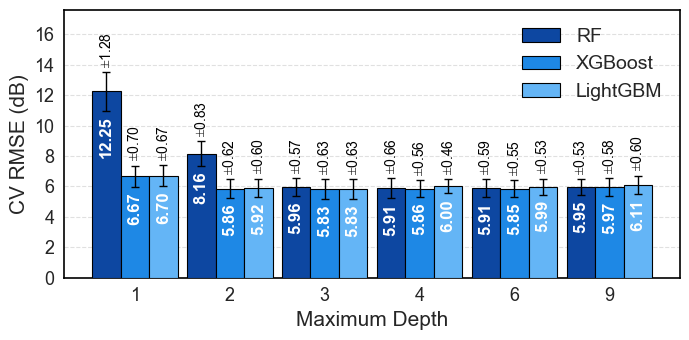

Saved figure: Figures/Ensembles_bestRMSE_STD_perDepth_comparison.png


In [4]:
# Plot and save the combined RF / XGBoost / LightGBM CV RMSE figure by max_depth

tick_fontsize   = 13
axis_labelsize  = 15
legend_fontsize = 14
value_fontsize  = 12
std_fontsize    = 10
y_tick_step     = 2  # dB spacing between y-axis ticks

# Blue-gradient theme: model identity is encoded by lightness (light -> dark)
model_order  = ["RF", "XGBoost", "LightGBM"]
model_colors = {
    "RF":       "#0d47a1",  # dark blue
    "XGBoost":  "#1e88e5",  # mid blue
    "LightGBM": "#64b5f6",  # light blue
}

depths = sorted(combined_cv_df["max_depth"].unique())   # every depth the three searches evaluated
plot_df = combined_cv_df

x = np.arange(len(depths))
n_models = len(model_order)
bar_width = 0.3

fig, ax = plt.subplots(figsize=(max(7.0, 0.8 * len(depths) + 1.0), 3.5))

for i, model in enumerate(model_order):
    sub = (
        plot_df[plot_df["model"] == model]
        .set_index("max_depth")
        .reindex(depths)
    )
    offset = (i - (n_models - 1) / 2) * bar_width
    bar_x = x + offset

    ax.bar(
        bar_x,
        sub["CV_RMSE"],
        bar_width,
        yerr=sub["STD_RMSE"],
        capsize=3,
        color=model_colors[model],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
        error_kw=dict(elinewidth=1, capthick=1),
        label=model,
    )

    for xi, cv, sd in zip(bar_x, sub["CV_RMSE"], sub["STD_RMSE"]):
        if pd.isna(cv):
            continue

        # Mean CV RMSE, set inside the bar near its lower error whisker
        ax.annotate(
            f"{cv:.2f}",
            (xi, cv - sd),
            textcoords="offset points",
            xytext=(0, -4),
            ha="center",
            va="top",
            fontsize=value_fontsize,
            color="white",
            fontweight="bold",
            rotation=90,
            zorder=4,
        )

        # SD, set above the upper error whisker
        ax.annotate(
            rf"$\pm${sd:.2f}",
            (xi, cv + sd),
            textcoords="offset points",
            xytext=(0, 3),
            ha="center",
            va="bottom",
            fontsize=std_fontsize,
            color="black",
            rotation=90,
            zorder=4,
        )

ax.set_xlabel("Maximum Depth", fontsize=axis_labelsize)
ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(d)}" for d in depths], fontsize=tick_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
ax.grid(False, axis="x")
ax.set_axisbelow(True)

y_top = float((plot_df["CV_RMSE"] + plot_df["STD_RMSE"]).max())
ax.set_ylim(0, y_top * 1.3)
ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

ax.legend(loc="upper right", fontsize=legend_fontsize, frameon=False)

fig.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "Ensembles_bestRMSE_STD_perDepth_comparison.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

plt.show()
print(f"Saved figure: {fig_path}")

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load: kNN CV Results
</p>

In [ ]:
# Best CV RMSE per evaluated K for kNN, from the saved BayesSearchCV cv_results_ table

def best_per_param(cv_results_path, param_col, out_name, param_cast=float):
    """Best (max score / min RMSE) CV RMSE and its SD per distinct value of
    `param_col`, from a saved BayesSearchCV cv_results_ table."""
    if not os.path.exists(cv_results_path):
        raise FileNotFoundError(f"Missing CV results file: {cv_results_path}")

    df = pd.read_csv(cv_results_path)
    required_cols = {
        param_col,
        "mean_test_neg_root_mean_squared_error",
        "std_test_neg_root_mean_squared_error",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{cv_results_path} is missing columns: {sorted(missing)}")

    df[param_col] = pd.to_numeric(df[param_col], errors="coerce")

    rows = []
    for value in sorted(df[param_col].dropna().unique()):
        df_value = df[df[param_col] == value]
        idx = df_value["mean_test_neg_root_mean_squared_error"].idxmax()
        row = df_value.loc[idx]
        rows.append({
            out_name: param_cast(value),
            "CV_RMSE": -float(row["mean_test_neg_root_mean_squared_error"]),
            "STD_RMSE": float(row["std_test_neg_root_mean_squared_error"]),
        })

    return pd.DataFrame(rows)



cv_knn_df = best_per_param(KNN_CV_RESULTS_PATH, "param_knn__n_neighbors", "K", param_cast=int)
display(cv_knn_df.round(4))


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plot: kNN CV RMSE by k
</p>

In [ ]:
# CV RMSE of every K the kNN search evaluated, with the selected K marked

tick_fontsize   = 12
axis_labelsize  = 15
legend_fontsize = 12

best = cv_knn_df.loc[cv_knn_df["CV_RMSE"].idxmin()]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.errorbar(cv_knn_df["K"], cv_knn_df["CV_RMSE"], yerr=cv_knn_df["STD_RMSE"], fmt="o", markersize=4, color=bar_color,
            ecolor="0.75", elinewidth=1, zorder=3, label="evaluated $k$ (mean ± SD over folds)")
ax.plot(best["K"], best["CV_RMSE"], marker="o", markersize=11, markerfacecolor="none", markeredgecolor="black", markeredgewidth=1.5,
        linestyle="None", zorder=4, label=f"selected $k$ = {int(best['K'])} ({best['CV_RMSE']:.2f} dB)")
ax.set_xlabel("$k$ (nearest neighbors)", fontsize=axis_labelsize)
ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)
ax.tick_params(axis="both", labelsize=tick_fontsize)
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)
ax.legend(fontsize=legend_fontsize, frameon=False)
fig.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "KNN_cv_rmse_by_K.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.show()
print(f"Saved figure: {fig_path}")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load: ANN CV Results
</p>

In [ ]:
# Best CV RMSE per screened ANN architecture

def load_arch_best_rmse(preferred_path, fallback_path):
    """Best CV RMSE and its SD for every architecture screened in 07_ANN.ipynb, from the
    best-profile-per-architecture table, or derived from the raw k-fold summary."""
    if os.path.exists(preferred_path):
        df = pd.read_csv(preferred_path)
    elif os.path.exists(fallback_path):
        df = pd.read_csv(fallback_path).sort_values("Mean Val RMSE").groupby("Architecture", as_index=False).head(1)
    else:
        raise FileNotFoundError(f"Missing CV results: {preferred_path} (or fallback {fallback_path})")

    required_cols = {"Hidden Layers", "Mean Val RMSE", "Std Val RMSE"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{preferred_path} is missing columns: {sorted(missing)}")

    df["arch_tuple"] = df["Hidden Layers"].apply(lambda v: tuple(int(n) for n in re.findall(r"\d+", str(v))))
    df["CV_RMSE"] = pd.to_numeric(df["Mean Val RMSE"], errors="coerce")
    df["STD_RMSE"] = pd.to_numeric(df["Std Val RMSE"], errors="coerce")
    df = df.dropna(subset=["CV_RMSE", "STD_RMSE"])
    df = df.loc[df.groupby("arch_tuple")["CV_RMSE"].idxmin()].copy()
    df["layers"] = df["arch_tuple"].apply(len)
    df["nodes"] = df["arch_tuple"].apply(sum)
    df = df.sort_values(["layers", "nodes"]).reset_index(drop=True)
    df["arch_label"] = df["arch_tuple"].apply(lambda t: ", ".join(map(str, t)))
    return df[["arch_label", "arch_tuple", "layers", "nodes", "CV_RMSE", "STD_RMSE"]]


cv_ann_df = load_arch_best_rmse(ANN_BEST_PROFILE_PATH, ANN_CV_RESULTS_PATH)
display(cv_ann_df.round(4))


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plot: ANN CV RMSE by architecture
</p>

In [ ]:
# CV RMSE of every screened ANN architecture (best regularisation profile each), selected architecture marked

tick_fontsize = 12
x = np.arange(len(cv_ann_df))
best_i = int(cv_ann_df["CV_RMSE"].idxmin())

fig, ax = plt.subplots(figsize=(max(7.0, 0.45 * len(cv_ann_df) + 1.5), 3.6))
ax.bar(x, cv_ann_df["CV_RMSE"], width=0.6, yerr=cv_ann_df["STD_RMSE"], capsize=4, color=bar_color, edgecolor="black", linewidth=1,
       zorder=3, error_kw=dict(elinewidth=1, capthick=1))
ax.bar(x[best_i], cv_ann_df["CV_RMSE"].iloc[best_i], width=0.6, color="none", edgecolor="black", linewidth=2.5, zorder=4,
       label=f"selected: ({cv_ann_df['arch_label'].iloc[best_i]}) at {cv_ann_df['CV_RMSE'].iloc[best_i]:.2f} dB")
for xi, cv, sd in zip(x, cv_ann_df["CV_RMSE"], cv_ann_df["STD_RMSE"]):
    annotate_bar(ax, xi, cv, sd)
ax.set_xticks(x)
ax.set_xticklabels(cv_ann_df["arch_label"], rotation=45, ha="right", fontsize=tick_fontsize)
y_top = float((cv_ann_df["CV_RMSE"] + cv_ann_df["STD_RMSE"]).max())
ax.set_ylim(0, y_top * 1.3)
style_panel(ax, "ANN architecture (hidden-layer widths)", "")
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.0), fontsize=11)   # above the axes, clear of the error-bar labels
fig.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "ANN_cv_rmse_by_architecture.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.show()
print(f"Saved figure: {fig_path}")
